# Phase 2 — Optimizations

We apply three optimization techniques, each targeting a profiled bottleneck:

1. **KV-Cache** — eliminate redundant key/value recomputation
2. **INT8 Quantization** — reduce weight memory and speed up matmul
3. **Async Batching** — process multiple prompts in a single forward pass

Each optimization is benchmarked independently, then we show cumulative results.

In [1]:
import sys
sys.path.insert(0, "..")

from src.model import load_model_and_tokenizer
from src.inference import generate, generate_manual
from src.kv_cache import generate_with_kv_cache
from src.quantization import quantize_model, generate_quantized, get_model_size_mb
from src.async_batching import generate_batched, run_batched_benchmark
from src.benchmark import run_benchmark, compare_benchmarks, plot_speedups
from src.profiling import (
    profile_generate, line_profile_function,
    memory_profile_generate, get_model_memory_footprint,
)
from src.config import BENCHMARK_PROMPTS, QUALITY_CHECK_PROMPTS

In [2]:
model, tokenizer = load_model_and_tokenizer()
print(f"Model: {model.config._name_or_path}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Model size: {get_model_size_mb(model):.1f} MB")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model: gpt2
Parameters: 124,439,808
Model size: 474.7 MB


---
## 1. Profiling the Baseline

Before optimizing, we identify exactly where time and memory are spent.

### 1a. cProfile (function-level)

In [3]:
cprofile_result = profile_generate(
    model, tokenizer, "The meaning of life is",
    generate_fn=generate_manual, max_new_tokens=50,
)
print(cprofile_result["profile_stats"])

         121954 function calls (105498 primitive calls) in 1.360 seconds

   Ordered by: cumulative time
   List reduced from 191 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    1.360    1.360 _contextlib.py:120(decorate_context)
        1    0.004    0.004    1.360    1.360 inference.py:60(generate_manual)
  7550/50    0.005    0.000    1.314    0.026 module.py:1775(_wrapped_call_impl)
  7550/50    0.010    0.000    1.314    0.026 module.py:1783(_call_impl)
       50    0.000    0.000    1.313    0.026 generic.py:870(wrapper)
       50    0.001    0.000    1.313    0.026 modeling_gpt2.py:656(forward)
       50    0.000    0.000    0.977    0.020 generic.py:890(wrapper)
       50    0.001    0.000    0.976    0.020 output_capturing.py:217(wrapper)
       50    0.003    0.000    0.975    0.019 modeling_gpt2.py:519(forward)
      600    0.001    0.000    0.961    0.002 modeling_layers.py:59(__call__)
  

### 1b. line_profiler (line-level hotspots)

In [4]:
lp_result = line_profile_function(
    generate_manual, model, tokenizer, "The meaning of life is", max_new_tokens=50,
)
print(lp_result["report"])

/Users/shriranjanpatil/Data/NYU/Spring_26/Adv_Python_DS/Final_Project/.venv/lib/python3.11/site-packages/line_profiler/line_profiler.py:529: UserWarning: Adding a function with a `.__wrapped__` attribute. You may want to profile the wrapped function by adding `generate_manual.__wrapped__` instead.
  self.add_function(impl)


Timer unit: 1e-09 s

Total time: 1.33775 s
File: /Users/shriranjanpatil/Data/NYU/Spring_26/Adv_Python_DS/Final_Project/notebooks/../src/inference.py
Function: generate_manual at line 60

Line #      Hits         Time  Per Hit   % Time  Line Contents
    60                                           @torch.no_grad()
    61                                           def generate_manual(
    62                                               model: PreTrainedModel,
    63                                               tokenizer: PreTrainedTokenizer,
    64                                               prompt: str,
    65                                               max_new_tokens: int = MAX_NEW_TOKENS,
    66                                               temperature: float = TEMPERATURE,
    67                                               top_k: int = TOP_K,
    68                                           ) -> dict:
    69                                               """
    70            

### 1c. Memory profiling

In [5]:
mem_result = memory_profile_generate(
    model, tokenizer, "The meaning of life is",
    generate_fn=generate_manual, max_new_tokens=50,
)
print(f"Peak memory during generation: {mem_result['peak_memory_mb']:.2f} MB")
print(f"\nTop allocations:")
for alloc in mem_result["top_allocations"][:10]:
    print(f"  {alloc['size_kb']:.1f} KB  ({alloc['count']} allocs)  {alloc['file']}")

Peak memory during generation: 0.12 MB

Top allocations:
  49.6 KB  (600 allocs)  /Users/shriranjanpatil/.local/share/uv/python/cpython-3.11.13-macos-aarch64-none/lib/python3.11/dataclasses.py:1250
  17.4 KB  (266 allocs)  /Users/shriranjanpatil/Data/NYU/Spring_26/Adv_Python_DS/Final_Project/.venv/lib/python3.11/site-packages/transformers/pytorch_utils.py:122
  10.9 KB  (167 allocs)  /Users/shriranjanpatil/Data/NYU/Spring_26/Adv_Python_DS/Final_Project/.venv/lib/python3.11/site-packages/transformers/cache_utils.py:99
  8.3 KB  (130 allocs)  /Users/shriranjanpatil/Data/NYU/Spring_26/Adv_Python_DS/Final_Project/.venv/lib/python3.11/site-packages/transformers/cache_utils.py:98
  4.1 KB  (71 allocs)  /Users/shriranjanpatil/Data/NYU/Spring_26/Adv_Python_DS/Final_Project/.venv/lib/python3.11/site-packages/transformers/cache_utils.py:120
  3.8 KB  (49 allocs)  /Users/shriranjanpatil/Data/NYU/Spring_26/Adv_Python_DS/Final_Project/.venv/lib/python3.11/site-packages/transformers/models/gpt2/mode

---
## 2. Baseline Benchmark

In [6]:
print("Benchmarking baseline (manual loop, no optimizations)...")
baseline_results = run_benchmark(
    model, tokenizer, generate_manual,
    label="baseline (no cache)",
    save_path="../benchmark_results/phase2_baseline.json",
)
print(f"Baseline: {baseline_results['overall_tok_per_sec_mean']:.2f} tok/s")

Benchmarking baseline (manual loop, no optimizations)...
  [1/10] Benchmarking: The meaning of life is...
  [2/10] Benchmarking: In a distant galaxy, a lone astronaut discovered...
  [3/10] Benchmarking: The Python programming language was created by...
  [4/10] Benchmarking: Once upon a time in a land far away,...
  [5/10] Benchmarking: The capital of France is...
  [6/10] Benchmarking: Explain how a neural network works:...
  [7/10] Benchmarking: The quick brown fox jumps over the...
  [8/10] Benchmarking: In the year 2050, technology has advanced to the p...
  [9/10] Benchmarking: What is 2 + 2? The answer is...
  [10/10] Benchmarking: The three laws of thermodynamics state that...
  Results saved to ../benchmark_results/phase2_baseline.json
Baseline: 18.34 tok/s


---
## 3. Optimization 1: KV-Cache

**Bottleneck:** Without caching, the model recomputes K/V projections for ALL previous tokens at every step — O(seq_len) redundant work per token.

**Fix:** Cache K/V tensors and only process the new token at each step.

In [7]:
# Quick sanity check
result = generate_with_kv_cache(model, tokenizer, "The meaning of life is", max_new_tokens=50)
print(f"KV-Cache tok/s: {result['tok_per_sec']:.2f}")
print(f"Text: {result['text'][:200]}")

KV-Cache tok/s: 71.66
Text: The meaning of life is that things are meant to be lived so far ahead of you that you'd be better off if you were already dead than if you were dead alive. What you should know first and foremost is t


In [8]:
print("Benchmarking KV-Cache...")
kv_results = run_benchmark(
    model, tokenizer, generate_with_kv_cache,
    label="+ KV-Cache",
    save_path="../benchmark_results/phase2_kv_cache.json",
)
print(f"KV-Cache: {kv_results['overall_tok_per_sec_mean']:.2f} tok/s")

Benchmarking KV-Cache...
  [1/10] Benchmarking: The meaning of life is...
  [2/10] Benchmarking: In a distant galaxy, a lone astronaut discovered...
  [3/10] Benchmarking: The Python programming language was created by...
  [4/10] Benchmarking: Once upon a time in a land far away,...
  [5/10] Benchmarking: The capital of France is...
  [6/10] Benchmarking: Explain how a neural network works:...
  [7/10] Benchmarking: The quick brown fox jumps over the...
  [8/10] Benchmarking: In the year 2050, technology has advanced to the p...
  [9/10] Benchmarking: What is 2 + 2? The answer is...
  [10/10] Benchmarking: The three laws of thermodynamics state that...
  Results saved to ../benchmark_results/phase2_kv_cache.json
KV-Cache: 72.95 tok/s


---
## 4. Optimization 2: INT8 Quantization

**Bottleneck:** FP32 weights (475 MB) consume memory bandwidth during matmul.

**Fix:** Quantize weights to INT8 (1 byte each), reducing memory ~4×. Dequantize on the fly during forward pass.

In [9]:
print("Quantizing model to INT8...")
quantized_model = quantize_model(model)
print(f"Original model size: {get_model_size_mb(model):.1f} MB")
print(f"Quantized model size: {get_model_size_mb(quantized_model):.1f} MB")
print(f"Reduction: {(1 - get_model_size_mb(quantized_model) / get_model_size_mb(model)) * 100:.1f}%")

Quantizing model to INT8...
Original model size: 474.7 MB
Quantized model size: 268.5 MB
Reduction: 43.4%


In [10]:
# Sanity check
result = generate_quantized(quantized_model, tokenizer, "The meaning of life is", max_new_tokens=50)
print(f"Quantized tok/s: {result['tok_per_sec']:.2f}")
print(f"Text: {result['text'][:200]}")

Quantized tok/s: 23.57
Text: The meaning of life is that the meaning of life is that the meaning of life is that the meaning of life is that the meaning of life is that the meaning of life is that the meaning of life is that the 


In [11]:
print("Benchmarking INT8 Quantization + KV-Cache...")
quant_results = run_benchmark(
    quantized_model, tokenizer, generate_quantized,
    label="+ Quantization (INT8)",
    save_path="../benchmark_results/phase2_quantized.json",
)
print(f"Quantized: {quant_results['overall_tok_per_sec_mean']:.2f} tok/s")

Benchmarking INT8 Quantization + KV-Cache...
  [1/10] Benchmarking: The meaning of life is...
  [2/10] Benchmarking: In a distant galaxy, a lone astronaut discovered...
  [3/10] Benchmarking: The Python programming language was created by...
  [4/10] Benchmarking: Once upon a time in a land far away,...
  [5/10] Benchmarking: The capital of France is...
  [6/10] Benchmarking: Explain how a neural network works:...
  [7/10] Benchmarking: The quick brown fox jumps over the...
  [8/10] Benchmarking: In the year 2050, technology has advanced to the p...
  [9/10] Benchmarking: What is 2 + 2? The answer is...
  [10/10] Benchmarking: The three laws of thermodynamics state that...
  Results saved to ../benchmark_results/phase2_quantized.json
Quantized: 23.94 tok/s


---
## 5. Optimization 3: Async Batching

**Bottleneck:** Processing one prompt at a time — fixed per-request overhead is paid repeatedly.

**Fix:** Batch multiple prompts into a single forward pass so matrix operations are larger and more hardware-efficient.

In [12]:
# Sanity check — batch of 4 prompts
batch_results = generate_batched(
    model, tokenizer,
    ["The meaning of life is", "In a distant galaxy,", "Python was created by", "The capital of France is"],
    max_new_tokens=50,
)
for r in batch_results:
    print(f"  [{r['tok_per_sec']:.1f} tok/s] {r['text'][:100]}")
    print()

  [37.1 tok/s] The meaning of life is one of freedom. If the idea is to be freedom, you must believe everything you

  [37.1 tok/s] In a distant galaxy, however, a race of massive space craft called the Y3M1 has settled back in the 

  [37.1 tok/s] Python was created by create share share share share share share share share share share share share

  [37.1 tok/s] The capital of France is also struggling to stem the flow of refugees into Germany, a government off



In [13]:
print("Benchmarking Async Batching (batch_size=4)...")
batch_bench = run_batched_benchmark(
    model, tokenizer, BENCHMARK_PROMPTS,
    batch_size=4, max_new_tokens=200,
)
print(f"Batched (bs=4): {batch_bench['overall_tok_per_sec_mean']:.2f} tok/s")

Benchmarking Async Batching (batch_size=4)...
Batched (bs=4): 140.67 tok/s


---
## 6. Cumulative Comparison

In [14]:
all_results = [baseline_results, kv_results, quant_results, batch_bench]
compare_benchmarks(all_results)


Label                       tok/s (mean)    tok/s (std)    Speedup
-----------------------------------------------------------------
baseline (no cache)                18.34           5.58      1.00x
+ KV-Cache                         72.95           2.00      3.98x
+ Quantization (INT8)              23.94           0.45      1.31x
async_batch_4                     140.67           3.45      7.67x


  Plot saved to ../benchmark_results/phase2_comparison.png


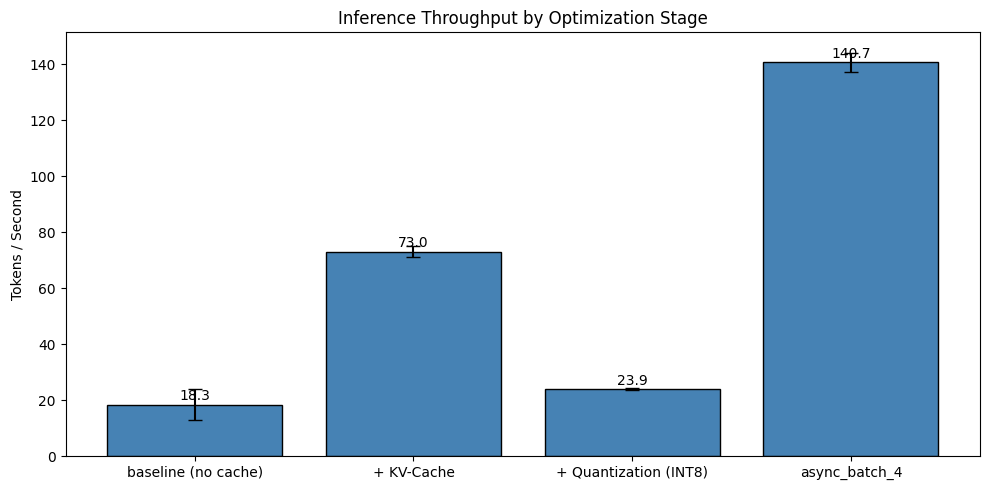

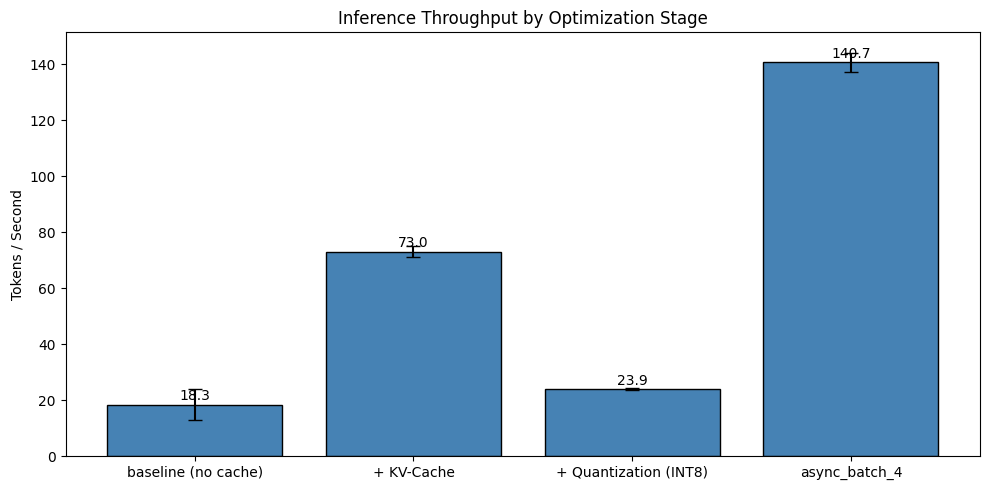

In [15]:
fig = plot_speedups(all_results, save_path="../benchmark_results/phase2_comparison.png")
fig

---
## 7. Quality Sanity Check

Verify outputs remain coherent after each optimization.

In [16]:
print("=" * 80)
for prompt in QUALITY_CHECK_PROMPTS:
    print(f"\nPrompt: {prompt}")
    
    baseline_out = generate_manual(model, tokenizer, prompt, max_new_tokens=30)
    print(f"  Baseline:    {baseline_out['text'][:120]}")
    
    kv_out = generate_with_kv_cache(model, tokenizer, prompt, max_new_tokens=30)
    print(f"  KV-Cache:    {kv_out['text'][:120]}")
    
    quant_out = generate_quantized(quantized_model, tokenizer, prompt, max_new_tokens=30)
    print(f"  Quantized:   {quant_out['text'][:120]}")
    
print("\n" + "=" * 80)


Prompt: What is 2 + 2? The answer is
  Baseline:    What is 2 + 2? The answer is 1 or 3; 2 was the standard. And if they've ever been asked whether God created 2 (as in, di
  KV-Cache:    What is 2 + 2? The answer is 1 . 2 + 1 = 2*(2 + 2)/2. This means we can use this argument and apply it with the other ar
  Quantized:   What is 2 + 2? The answer is not that simple. One doesn't have many weapons during combat. One only has two weapons duri

Prompt: The capital of France is
  Baseline:    The capital of France is France and I have not been to the scene, but it would be nice to meet. I've never met the perso
  KV-Cache:    The capital of France is ruled by a military bureaucracy which has been led since the 1860s by its own dictator.

Since 
  Quantized:   The capital of France is the scene of an ethnic cleansing scandal. On the other hand, one in three people in Marseille a

Prompt: Water freezes at
  Baseline:    Water freezes at a rate of about 1 kilogram-hours per second, meaning t

---
## 8. Memory Comparison

In [17]:
print(f"Original model:  {get_model_size_mb(model):.1f} MB")
print(f"Quantized model: {get_model_size_mb(quantized_model):.1f} MB")
print(f"\nOriginal footprint:")
for k, v in get_model_memory_footprint(model).items():
    print(f"  {k}: {v}")
print(f"\nQuantized footprint:")
for k, v in get_model_memory_footprint(quantized_model).items():
    print(f"  {k}: {v}")

Original model:  474.7 MB
Quantized model: 268.5 MB

Original footprint:
  num_parameters: 124439808
  param_memory_mb: 474.7001953125
  buffer_memory_mb: 0.0
  total_memory_mb: 474.7001953125
  dtype: torch.float32

Quantized footprint:
  num_parameters: 39422208
  param_memory_mb: 150.3837890625
  buffer_memory_mb: 118.12591934204102
  total_memory_mb: 268.509708404541
  dtype: torch.float32


---
## Summary

| Optimization | Technique | Bottleneck Addressed | Course Tool |
|---|---|---|---|
| KV-Cache | Cache K/V tensors across steps | Redundant attention recomputation | NumPy, PyTorch |
| Quantization | INT8 weights + dequantize on fly | FP32 memory bandwidth | Numba, NumPy |
| Async Batching | Batch prompts in single forward pass | Per-request overhead, underutilized HW | asyncio |